# Exercise 12: Deep Learning for Time Series

*Luca Kyburz, Pascal Gansner, Sofia Horlacher, David Schurtenberger*

**Dataset:** AirPassengers - Monthly airline passenger numbers from 1949-1960

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from torch.utils.data import Dataset, DataLoader

from utils import (
    get_figure,
    time_plot,
    acf_plot,
    pacf_plot,
    stationarity_tests
)

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


# 1. Data Loading and Exploration

In [4]:
# Load AirPassengers dataset
data = sm.datasets.get_rdataset('AirPassengers').data
print(f"\nDataset shape: {data.shape}")
print(f"\nFirst few rows:\n{data.head()}")


Dataset shape: (144, 2)

First few rows:
          time  value
0  1949.000000    112
1  1949.083333    118
2  1949.166667    132
3  1949.250000    129
4  1949.333333    121


In [5]:
# Convert to proper time series format
data['time'] = pd.date_range(start='1949-01-01', periods=len(data), freq='MS')
data = data.set_index('time')
data["value"] = data["value"].astype("float")
data = data.rename(columns={'value': 'Passengers'})

In [6]:
print(f"\nTime series range: {data.index[0]} to {data.index[-1]}")
print(f"Total observations: {len(data)}")


Time series range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Total observations: 144


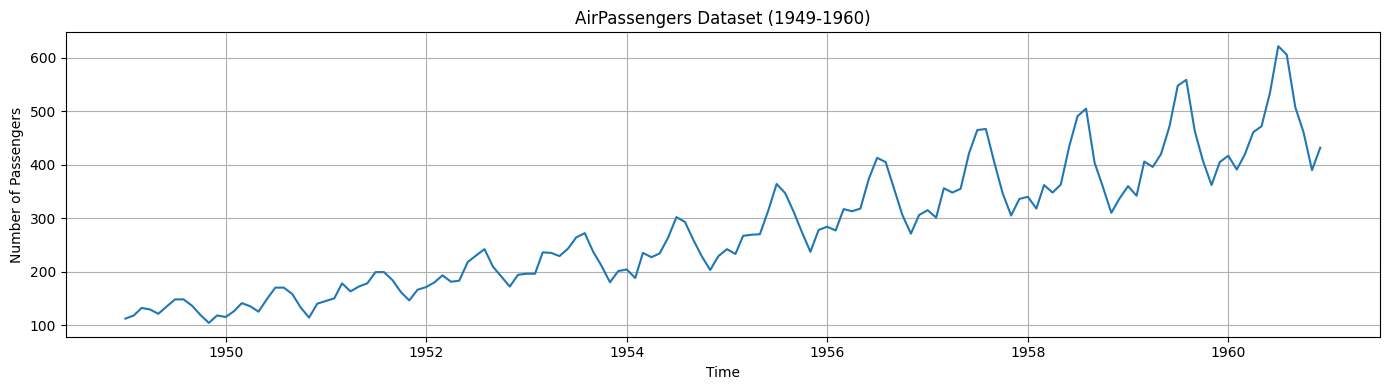

In [7]:
# Visualize the data
fig, ax = get_figure(ncols=1, figsize=(14, 4))
time_plot(x=data.index, y=data['Passengers'],
          title='AirPassengers Dataset (1949-1960)',
          xlabel='Time', ylabel='Number of Passengers', ax=ax[0])
plt.tight_layout()
plt.show()

The AirPassengers dataset shows three clear characteristics:
1. **Strong upward trend**
2. **Annual Seasonal pattern**
3. **Increasing variance over time**

## 1.1 Stationarity Analysis

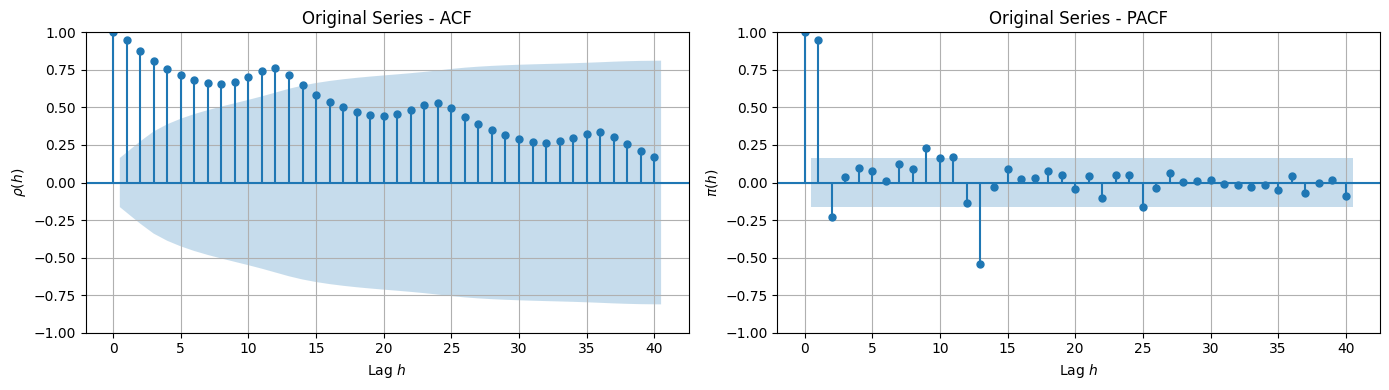

In [8]:
fig, axs = get_figure(ncols=2, figsize=(14, 4))
acf_plot(data['Passengers'], nlags=40, ax=axs[0], title='Original Series - ACF', prefix_title=False)
pacf_plot(data['Passengers'], nlags=40, ax=axs[1], title='Original Series - PACF', prefix_title=False)
plt.tight_layout()
plt.show()

In [9]:
stationarity_tests(data["Passengers"])

Stationarity Test Results:
	- ADF: Non-Stationary (p-value: 0.9919)
	- PP: Non-Stationary (p-value: 0.6055)
	- KPSS: Non-Stationary (p-value: 0.0001)
	- ZA: Non-Stationary (p-value: 0.5808)


The original time series is clearly non-stationary, shown by the strong trend and seasonal pattern visible in the plot. The ACF shows a slow decay typical of non-stationary data with positive trend and seasonality, and the PACF confirms the presence of significant autocorrelation. Statistical tests also reject stationarity, indicating we need transformations before applying certain statistical models.

## 1.2 Making Data Stationary

Applying transformations to achieve stationarity:
- First differencing to remove trend
- Seasonal differencing to remove seasonality (12 months) and variance stabilization

In [10]:
data['Diff'] = data['Passengers'].diff() # First order differencing to remove trend
data['Seasonal'] = data['Passengers'].diff(12) # Seasonal differencing (12 months)
data['Diff_Seasonal'] = data['Passengers'].diff().diff(12) # Combined: first + seasonal differencing (12 months)

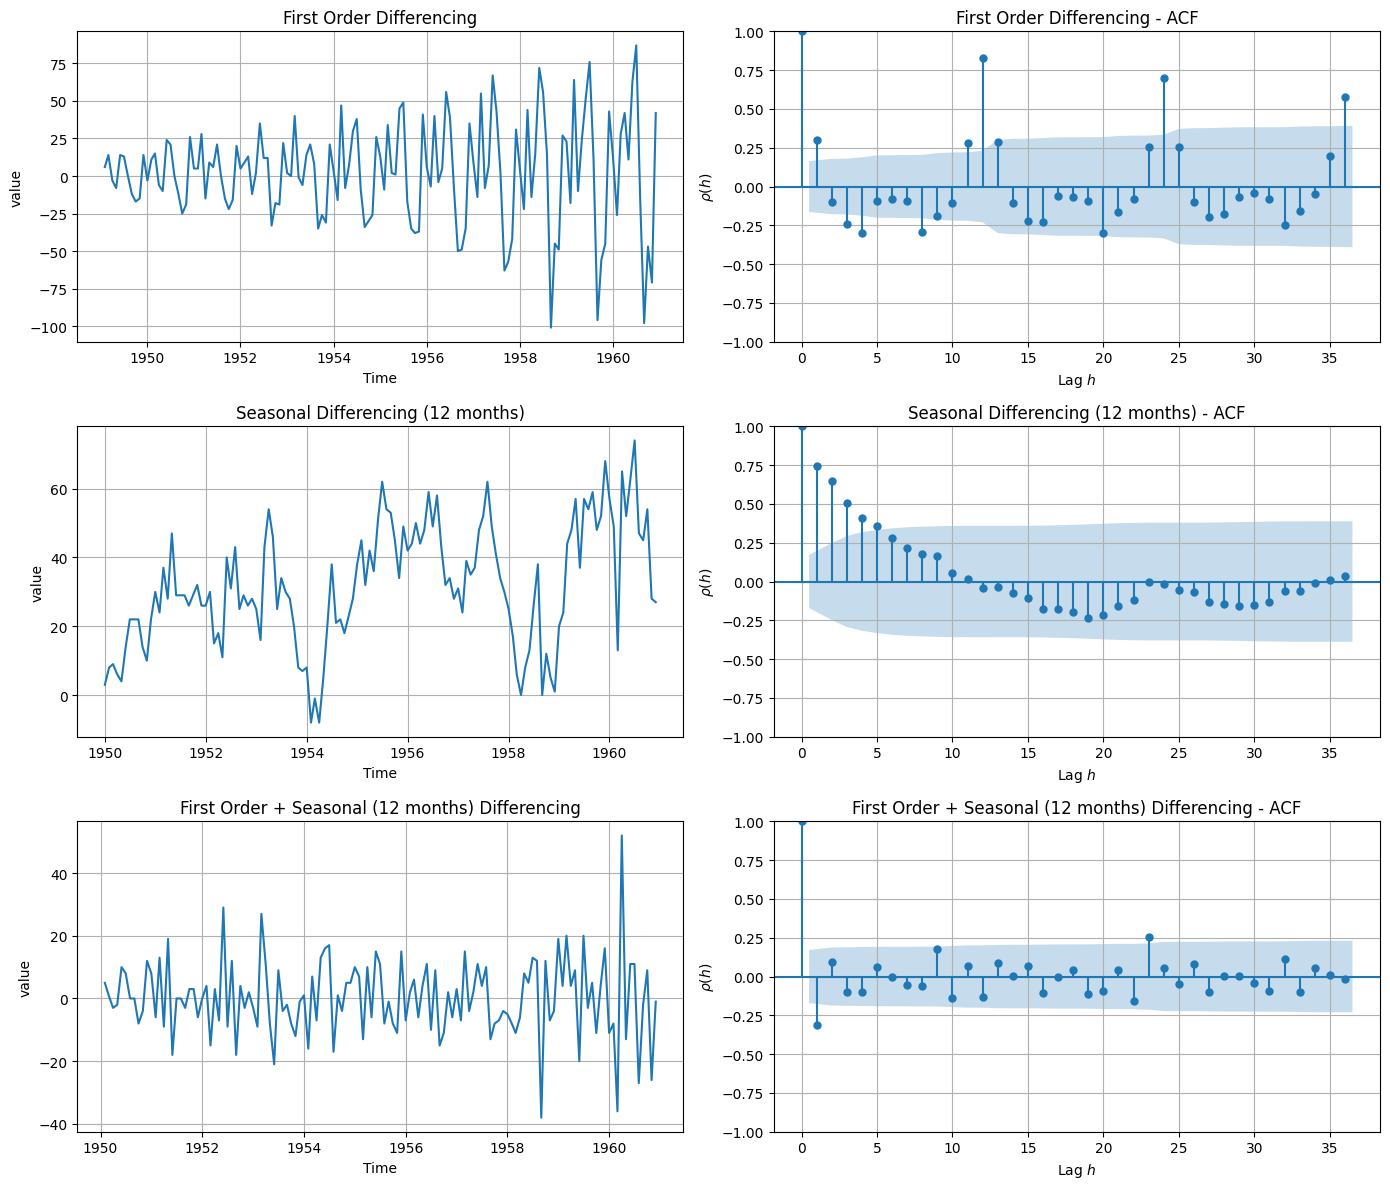

In [11]:
# Visualize transformations
fig, axs = get_figure(nrows=3, ncols=2, figsize=(14, 12))
time_plot(data.index[1:], data['Diff'].dropna(), ax=axs[0], title='First Order Differencing', xlabel='Time', ylabel='value', prefix_title=False)
acf_plot(data['Diff'].dropna(), nlags=len(data)//4, ax=axs[1], title='First Order Differencing - ACF', prefix_title=False)
time_plot(data.index[12:], data['Seasonal'].dropna(), ax=axs[2], title='Seasonal Differencing (12 months)', xlabel='Time', ylabel='value', prefix_title=False)
acf_plot(data['Seasonal'].dropna(), nlags=len(data)//4, ax=axs[3], title='Seasonal Differencing (12 months) - ACF', prefix_title=False)
time_plot(data.index[13:], data['Diff_Seasonal'].dropna(), ax=axs[4], title='First Order + Seasonal (12 months) Differencing', xlabel='Time', ylabel='value', prefix_title=False)
acf_plot(data['Diff_Seasonal'].dropna(), nlags=len(data)//4, ax=axs[5], title='First Order + Seasonal (12 months) Differencing - ACF', prefix_title=False)
plt.tight_layout()
plt.show()

In [12]:
for col in ['Diff', 'Seasonal', 'Diff_Seasonal']:
    print(f"\n{col}:")
    stationarity_tests(data[col].dropna())


Diff:
Stationarity Test Results:
	- ADF: Non-Stationary (p-value: 0.0542)
	- PP: Stationary (p-value: 0.0000)
	- KPSS: Stationary (p-value: 0.9917)
	- ZA: Non-Stationary (p-value: 0.7693)

Seasonal:
Stationarity Test Results:
	- ADF: Stationary (p-value: 0.0116)
	- PP: Stationary (p-value: 0.0002)
	- KPSS: Non-Stationary (p-value: 0.0329)
	- ZA: Non-Stationary (p-value: 0.4136)

Diff_Seasonal:
Stationarity Test Results:
	- ADF: Stationary (p-value: 0.0000)
	- PP: Stationary (p-value: 0.0000)
	- KPSS: Stationary (p-value: 0.8963)
	- ZA: Stationary (p-value: 0.0000)


The transformations successfully achieve stationarity:
- **First differencing** removes the trend but seasonality remains visible in ACF
- **Seasonal differencing (12 months)** removes the yearly seasonal pattern and variance stabilizes
- **Combined differencing** (first order + seasonal) produces stationary results as confirmed by the statistical tests and ACF plots

The combined differenced series also passes the stationarity tests, making it suitable for use as stationary input data

# 3. Deep Learning Models - LSTM & GRU

We implement LSTM and GRU models for time series forecasting. These recurrent neural networks are designed to capture temporal dependencies and patterns in sequential data.

In [13]:
# Configuration parameters
CONFIG = {
    'train_split': 0.8,          # 80-20 train-test split
    'lookback': 12,              # Use 12 months of history
    'horizon': 1,                # Predict 1 month ahead
    'dl_hidden_size': 128,        # Hidden layer size for DL models
    'dl_num_layers': 3,          # Number of LSTM/GRU layers
    'dl_dropout': 0.2,           # Dropout rate
    'dl_epochs': 100,            # Maximum training epochs
    'dl_lr': 1e-3,              # Learning rate
    'dl_batch_size': 8,          # Batch size
    'dl_patience': 15,           # Early stopping patience
    'rf_estimators': 100,        # Random Forest trees
    'gb_estimators': 100,        # Gradient Boosting trees
}

In [14]:
# Create PyTorch Dataset
class TimeSeriesDataset(Dataset):
    """
    PyTorch Dataset for time series data.
    Creates sequences of length 'lookback' to predict 'horizon' steps ahead.
    """
    def __init__(self, data, lookback=12, horizon=1):
        self.data = torch.FloatTensor(data.dropna().values)
        self.lookback = lookback
        self.horizon = horizon

    def __len__(self):
        return len(self.data) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.lookback]
        y = self.data[idx+self.lookback:idx+self.lookback+self.horizon]
        return x.unsqueeze(-1), y  # Add feature dimension

In [18]:
# LSTM Model
class LSTMModel(nn.Module):
    """
    LSTM model for time series forecasting.
    Uses multiple LSTM layers with dropout for regularization.
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, horizon=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # Take the last time step
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output

In [19]:
# GRU Model
class GRUModel(nn.Module):
    """
    GRU model for time series forecasting.
    Similar to LSTM but with simpler gating mechanism.
    """
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, horizon=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                         batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        gru_out, _ = self.gru(x)
        # Take the last time step
        last_output = gru_out[:, -1, :]
        output = self.fc(last_output)
        return output

In [20]:
# Deep Neural Network (DNN) Model
class DNNModel(nn.Module):
    """
    Simple feedforward neural network for time series forecasting.
    Takes the lookback window as a flattened input vector.
    """
    def __init__(self, lookback=12, hidden_size=64, num_layers=3, dropout=0.2, horizon=1):
        super(DNNModel, self).__init__()

        layers = []
        input_size = lookback

        for i in range(num_layers):
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            input_size = hidden_size

        layers.append(nn.Linear(hidden_size, horizon))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        # Flatten the sequence dimension
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        output = self.network(x_flat)
        return output

In [21]:
# Training function
def train_dl_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=10):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5, verbose=True)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_train_loss = float('inf')
    best_model_state = model.state_dict()
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                output = model(x_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_loss = train_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_model_state)
    return model, best_train_loss, best_val_loss

In [22]:
# Prediction function
def predict_dl_model(model, data, lookback=12):
    model.eval()
    predictions = []

    with torch.no_grad():
        for i in range(len(data) - lookback):
            x = torch.FloatTensor(data[i:i+lookback].values).unsqueeze(0).unsqueeze(-1).to(device)
            pred = model(x)
            predictions.append(pred.cpu().numpy()[0, 0])

    return np.array(predictions)

## 3.1 Train DL Models on Original Data

Training LSTM and GRU models on the original (non-stationary) data as a baseline

In [23]:
lookback = CONFIG['lookback']
horizon = CONFIG['horizon']
batch_size = CONFIG['dl_batch_size']

### Train-Test Split

In [24]:
non_stat_data = data['Passengers'].dropna()

In [25]:
# Use 80-20 split
train_size = int(len(non_stat_data) * CONFIG['train_split'])
test_size = len(non_stat_data) - train_size

In [26]:
print(f"\nTrain size: {train_size} observations")
print(f"Test size: {test_size} observations")
print(f"Train period: {non_stat_data.index[0]} to {non_stat_data.index[train_size-1]}")
print(f"Test period: {non_stat_data.index[train_size]} to {non_stat_data.index[-1]}")


Train size: 115 observations
Test size: 29 observations
Train period: 1949-01-01 00:00:00 to 1958-07-01 00:00:00
Test period: 1958-08-01 00:00:00 to 1960-12-01 00:00:00


In [27]:
# Prepare data
train_data_orig = non_stat_data.iloc[:train_size].dropna()
test_data_orig = non_stat_data.iloc[train_size:].dropna()

In [28]:
# Normalize data
scaler_orig = StandardScaler()
train_data_scaled = scaler_orig.fit_transform(train_data_orig.values.reshape(-1, 1)).flatten()
test_data_scaled = scaler_orig.transform(test_data_orig.values.reshape(-1, 1)).flatten()

In [29]:
# Create datasets
full_data_scaled = np.concatenate([train_data_scaled, test_data_scaled])
train_dataset = TimeSeriesDataset(pd.Series(train_data_scaled), lookback, horizon)
val_size = int(len(train_dataset) * 0.2)
train_subset = torch.utils.data.Subset(train_dataset, range(len(train_dataset) - val_size))
val_subset = torch.utils.data.Subset(train_dataset, range(len(train_dataset) - val_size, len(train_dataset)))

In [30]:
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

In [31]:
# Train LSTM on original data
print("\n--- Training LSTM on Original Data ---")
lstm_model_orig = LSTMModel(input_size=1,
                           hidden_size=CONFIG['dl_hidden_size'],
                           num_layers=CONFIG['dl_num_layers'],
                           dropout=CONFIG['dl_dropout'],
                           horizon=horizon)
lstm_model_orig, lstm_train_loss, lstm_val_loss = train_dl_model(
    lstm_model_orig, train_loader, val_loader,
    epochs=CONFIG['dl_epochs'],
    lr=CONFIG['dl_lr'],
    patience=CONFIG['dl_patience']
)
print(f"Train loss: {lstm_train_loss:.6f}, Val loss: {lstm_val_loss:.6f}")


--- Training LSTM on Original Data ---
Epoch [10/100], Train Loss: 0.118725, Val Loss: 0.413048
Epoch [20/100], Train Loss: 0.092328, Val Loss: 0.447364
Epoch [30/100], Train Loss: 0.107014, Val Loss: 0.310936
Epoch [40/100], Train Loss: 0.077738, Val Loss: 0.297266
Epoch [50/100], Train Loss: 0.072105, Val Loss: 0.237035
Epoch [60/100], Train Loss: 0.063775, Val Loss: 0.177249
Epoch [70/100], Train Loss: 0.062416, Val Loss: 0.109299
Epoch [80/100], Train Loss: 0.050199, Val Loss: 0.241961
Epoch [90/100], Train Loss: 0.042469, Val Loss: 0.248408
Early stopping at epoch 91
Train loss: 0.048129, Val loss: 0.079911


In [32]:
# Train GRU on original data
print("\n--- Training GRU on Original Data ---")
gru_model_orig = GRUModel(input_size=1,
                         hidden_size=CONFIG['dl_hidden_size'],
                         num_layers=CONFIG['dl_num_layers'],
                         dropout=CONFIG['dl_dropout'],
                         horizon=horizon)
gru_model_orig, gru_train_loss, gru_val_loss = train_dl_model(
    gru_model_orig, train_loader, val_loader,
    epochs=CONFIG['dl_epochs'],
    lr=CONFIG['dl_lr'],
    patience=CONFIG['dl_patience']
)
print(f"Train loss: {gru_train_loss:.6f}, Val loss: {gru_val_loss:.6f}")


--- Training GRU on Original Data ---
Epoch [10/100], Train Loss: 0.102553, Val Loss: 0.254700
Epoch [20/100], Train Loss: 0.044924, Val Loss: 0.131076
Epoch [30/100], Train Loss: 0.034932, Val Loss: 0.138110
Epoch [40/100], Train Loss: 0.027494, Val Loss: 0.143164
Early stopping at epoch 41
Train loss: 0.037237, Val loss: 0.073132


In [33]:
# Train DNN on original data
print("\n--- Training DNN on Original Data ---")
dnn_model_orig = DNNModel(lookback=lookback,
                         hidden_size=CONFIG['dl_hidden_size'],
                         num_layers=CONFIG['dl_num_layers'],
                         dropout=CONFIG['dl_dropout'],
                         horizon=horizon)
dnn_model_orig, dnn_train_loss, dnn_val_loss = train_dl_model(
    dnn_model_orig, train_loader, val_loader,
    epochs=CONFIG['dl_epochs'],
    lr=CONFIG['dl_lr'],
    patience=CONFIG['dl_patience']
)
print(f"Train loss: {dnn_train_loss:.6f}, Val loss: {dnn_val_loss:.6f}")


--- Training DNN on Original Data ---
Epoch [10/100], Train Loss: 0.031359, Val Loss: 0.212514
Epoch [20/100], Train Loss: 0.031691, Val Loss: 0.060701
Epoch [30/100], Train Loss: 0.031940, Val Loss: 0.037718
Epoch [40/100], Train Loss: 0.032362, Val Loss: 0.054368
Epoch [50/100], Train Loss: 0.020528, Val Loss: 0.047621
Early stopping at epoch 56
Train loss: 0.017561, Val loss: 0.026956


In [34]:
# Make predictions
lstm_preds_scaled = predict_dl_model(lstm_model_orig, pd.Series(full_data_scaled), lookback)
gru_preds_scaled = predict_dl_model(gru_model_orig, pd.Series(full_data_scaled), lookback)
dnn_preds_scaled = predict_dl_model(dnn_model_orig, pd.Series(full_data_scaled), lookback)

In [35]:
# Inverse transform predictions
lstm_preds_orig = scaler_orig.inverse_transform(lstm_preds_scaled.reshape(-1, 1)).flatten()
gru_preds_orig = scaler_orig.inverse_transform(gru_preds_scaled.reshape(-1, 1)).flatten()
dnn_preds_orig = scaler_orig.inverse_transform(dnn_preds_scaled.reshape(-1, 1)).flatten()

In [36]:
# Evaluate on test set
test_start_idx = train_size - lookback
lstm_test_preds = lstm_preds_orig[test_start_idx:]
gru_test_preds = gru_preds_orig[test_start_idx:]
dnn_test_preds = dnn_preds_orig[test_start_idx:]

In [37]:
lstm_mse_orig = mean_squared_error(test_data_orig, lstm_test_preds)
lstm_mae_orig = mean_absolute_error(test_data_orig, lstm_test_preds)
gru_mse_orig = mean_squared_error(test_data_orig, gru_test_preds)
gru_mae_orig = mean_absolute_error(test_data_orig, gru_test_preds)
dnn_mse_orig = mean_squared_error(test_data_orig, dnn_test_preds)
dnn_mae_orig = mean_absolute_error(test_data_orig, dnn_test_preds)

LSTM - Original Data - MSE: 11733.33, MAE: 89.25
GRU - Original Data - MSE: 4677.74, MAE: 60.17
DNN - Original Data - MSE: 455.47, MAE: 16.41


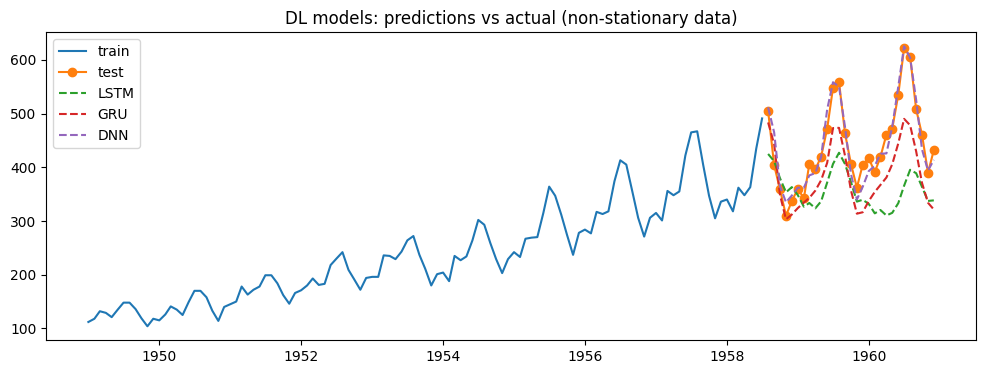

In [38]:
print(f"LSTM - Original Data - MSE: {lstm_mse_orig:.2f}, MAE: {lstm_mae_orig:.2f}")
print(f"GRU - Original Data - MSE: {gru_mse_orig:.2f}, MAE: {gru_mae_orig:.2f}")
print(f"DNN - Original Data - MSE: {dnn_mse_orig:.2f}, MAE: {dnn_mae_orig:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_data_orig.index, train_data_orig.values, label='train')
ax.plot(test_data_orig.index, test_data_orig.values, label='test', marker='o')
ax.plot(test_data_orig.index, lstm_test_preds, label='LSTM', linestyle='--')
ax.plot(test_data_orig.index, gru_test_preds, label='GRU', linestyle='--')
ax.plot(test_data_orig.index, dnn_test_preds, label='DNN', linestyle='--')
ax.set_title('DL models: predictions vs actual (non-stationary data)')
ax.legend()
plt.show()

All three models show some ability to learn the most obvious patterns in the data, but performance differs significantly. The LSTM performs worst with a MAE of 89.25, failing to capture the positive trend and also struggling with seasonality. The GRU does better with a MAE of 60.17, capturing both trend and seasonality better. The DNN performs best with a MAE of 16.41, following the test data very closely, capturing both trend and seasonality effectively.

## 3.2 Train DL Models on Stationary Data

Training LSTM and GRU models on stationary data (log-differenced) to improve performance

In [39]:
stat_data = data['Diff_Seasonal'].dropna()

In [40]:
# Use 80-20 split
train_size = int(len(stat_data) * CONFIG['train_split'])
test_size = len(stat_data) - train_size

In [41]:
print(f"\nTrain size: {train_size} observations")
print(f"Test size: {test_size} observations")
print(f"Train period: {stat_data.index[0]} to {stat_data.index[train_size-1]}")
print(f"Test period: {stat_data.index[train_size]} to {stat_data.index[-1]}")


Train size: 104 observations
Test size: 27 observations
Train period: 1950-02-01 00:00:00 to 1958-09-01 00:00:00
Test period: 1958-10-01 00:00:00 to 1960-12-01 00:00:00


In [42]:
# Use log-transformed data
train_data_stat = stat_data.iloc[:train_size].dropna()
test_data_stat = stat_data.iloc[train_size:].dropna()

In [43]:
# Normalize
scaler_log = StandardScaler()
train_data_stat_scaled = scaler_log.fit_transform(train_data_stat.values.reshape(-1, 1)).flatten()
test_data_stat_scaled = scaler_log.transform(test_data_stat.values.reshape(-1, 1)).flatten()

In [44]:
# Create datasets
full_data_stat_scaled = np.concatenate([train_data_stat_scaled, test_data_stat_scaled])
train_dataset_stat = TimeSeriesDataset(pd.Series(train_data_stat_scaled), lookback, horizon)
train_subset_stat = torch.utils.data.Subset(train_dataset_stat, range(len(train_dataset_stat) - val_size))
val_subset_stat = torch.utils.data.Subset(train_dataset_stat, range(len(train_dataset_stat) - val_size, len(train_dataset_stat)))

In [45]:
train_loader_stat = DataLoader(train_subset_stat, batch_size=batch_size, shuffle=True)
val_loader_stat = DataLoader(val_subset_stat, batch_size=batch_size, shuffle=False)

In [46]:
# Train LSTM on stationary data
print("\n--- Training LSTM on Stationary Data ---")
lstm_model_log = LSTMModel(input_size=1,
                          hidden_size=CONFIG['dl_hidden_size'],
                          num_layers=CONFIG['dl_num_layers'],
                          dropout=CONFIG['dl_dropout'],
                          horizon=horizon)
lstm_model_log, lstm_train_loss, lstm_val_loss = train_dl_model(
    lstm_model_log, train_loader_stat, val_loader_stat, epochs=CONFIG['dl_epochs'],
    lr=CONFIG['dl_lr'],
    patience=CONFIG['dl_patience']
)
print(f"Train loss: {lstm_train_loss:.6f}, Val loss: {lstm_val_loss:.6f}")


--- Training LSTM on Stationary Data ---
Epoch [10/100], Train Loss: 0.992340, Val Loss: 1.725764
Epoch [20/100], Train Loss: 0.867335, Val Loss: 1.492818
Epoch [30/100], Train Loss: 0.737774, Val Loss: 2.063784
Early stopping at epoch 35
Train loss: 0.867335, Val loss: 1.492818


In [47]:
# Train GRU on stationary data
print("\n--- Training GRU on Stationary Data ---")
gru_model_log = GRUModel(input_size=1,
                        hidden_size=CONFIG['dl_hidden_size'],
                        num_layers=CONFIG['dl_num_layers'],
                        dropout=CONFIG['dl_dropout'],
                        horizon=horizon)
gru_model_log, gru_train_loss, gru_val_loss = train_dl_model(
    gru_model_log, train_loader_stat, val_loader_stat, epochs=CONFIG['dl_epochs'],
    lr=CONFIG['dl_lr'],
    patience=CONFIG['dl_patience']
)
print(f"Train loss: {gru_train_loss:.6f}, Val loss: {gru_val_loss:.6f}")


--- Training GRU on Stationary Data ---
Epoch [10/100], Train Loss: 0.968709, Val Loss: 1.630992
Epoch [20/100], Train Loss: 0.855230, Val Loss: 1.701106
Early stopping at epoch 26
Train loss: 0.969062, Val loss: 1.600768


In [48]:
# Train DNN on stationary data
print("\n--- Training DNN on Stationary Data ---")
dnn_model_stat = DNNModel(lookback=lookback,
                         hidden_size=CONFIG['dl_hidden_size'],
                         num_layers=CONFIG['dl_num_layers'],
                         dropout=CONFIG['dl_dropout'],
                         horizon=horizon)
dnn_model_stat, dnn_train_loss, dnn_val_loss = train_dl_model(
    dnn_model_stat, train_loader_stat, val_loader_stat, epochs=CONFIG['dl_epochs'],
    lr=CONFIG['dl_lr'],
    patience=CONFIG['dl_patience']
)
print(f"Train loss: {dnn_train_loss:.6f}, Val loss: {dnn_val_loss:.6f}")


--- Training DNN on Stationary Data ---
Epoch [10/100], Train Loss: 0.580160, Val Loss: 2.201126
Early stopping at epoch 16
Train loss: 1.027762, Val loss: 1.778503


In [49]:
# Make predictions and inverse transform
lstm_preds_stat_scaled = predict_dl_model(lstm_model_log, pd.Series(full_data_stat_scaled), lookback)
gru_preds_stat_scaled = predict_dl_model(gru_model_log, pd.Series(full_data_stat_scaled), lookback)
dnn_preds_stat_scaled = predict_dl_model(dnn_model_stat, pd.Series(full_data_stat_scaled), lookback)

In [50]:
lstm_preds_stat = scaler_log.inverse_transform(lstm_preds_stat_scaled.reshape(-1, 1)).flatten()
gru_preds_stat = scaler_log.inverse_transform(gru_preds_stat_scaled.reshape(-1, 1)).flatten()
dnn_preds_stat = scaler_log.inverse_transform(dnn_preds_stat_scaled.reshape(-1, 1)).flatten()

In [51]:
# Evaluate on test set
test_start_idx = train_size - lookback
lstm_test_preds = lstm_preds_stat[test_start_idx:]
gru_test_preds = gru_preds_stat[test_start_idx:]
dnn_test_preds = dnn_preds_stat[test_start_idx:]

In [52]:
lstm_mse_stat = mean_squared_error(test_data_stat, lstm_test_preds)
lstm_mae_stat = mean_absolute_error(test_data_stat, lstm_test_preds)
gru_mse_stat = mean_squared_error(test_data_stat, gru_test_preds)
gru_mae_stat = mean_absolute_error(test_data_stat, gru_test_preds)
dnn_mse_stat = mean_squared_error(test_data_stat, dnn_test_preds)
dnn_mae_stat = mean_absolute_error(test_data_stat, dnn_test_preds)

LSTM - Stationary Data - MSE: 373.63, MAE: 14.60
GRU - Stationary Data - MSE: 322.78, MAE: 14.31
DNN - Stationary Data - MSE: 248.91, MAE: 12.10


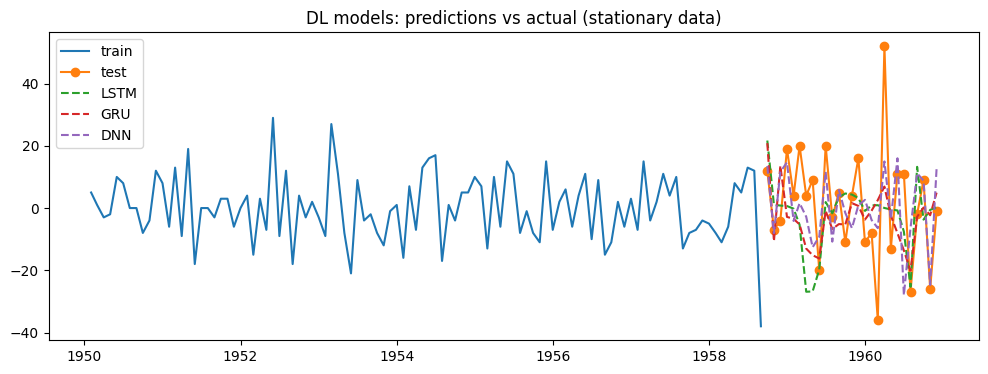

In [53]:
print(f"LSTM - Stationary Data - MSE: {lstm_mse_stat:.2f}, MAE: {lstm_mae_stat:.2f}")
print(f"GRU - Stationary Data - MSE: {gru_mse_stat:.2f}, MAE: {gru_mae_stat:.2f}")
print(f"DNN - Stationary Data - MSE: {dnn_mse_stat:.2f}, MAE: {dnn_mae_stat:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_data_stat.index, train_data_stat.values, label='train')
ax.plot(test_data_stat.index, test_data_stat.values, label='test', marker='o')
ax.plot(test_data_stat.index, lstm_test_preds, label='LSTM', linestyle='--')
ax.plot(test_data_stat.index, gru_test_preds, label='GRU', linestyle='--')
ax.plot(test_data_stat.index, dnn_test_preds, label='DNN', linestyle='--')
ax.set_title('DL models: predictions vs actual (stationary data)')
ax.legend()
plt.show()

In absolute terms, the models perform better on the stationary data with MAE's between 12.1 and 14.6, with both LSTM and GRU improving significantly on the original data results. However, the patterns shown in the stationary data were not closely predicted by any of the models, indicating that most of the original data could possibly be captured by statistical methods alone. Again, the DNN model performed best, capturing at least some of the patterns shown in the stationary data, however its MAE of 12.1 is not too far away from the variance of the data itself.

# 4. Machine Learning Models

Training Random Forest and Gradient Boosting models with lag features

In [54]:
# Create lag features
def create_features(data, n_lags=12):
    df = pd.DataFrame({'y': data})
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['y'].shift(i)
        if i > 1:
            df[f"roll_{i}"] = df['y'].rolling(window=i, min_periods=1, closed='right').mean()
    df = df.dropna()
    X = df.drop('y', axis=1)
    y = df['y']
    return X, y

In [55]:
# Prepare data for ML models
X_train, y_train = create_features(train_data_orig, n_lags=12)
X_test_ml = pd.DataFrame()

In [56]:
# Create test features by rolling through the data
full_series = pd.concat([train_data_orig, test_data_orig])
for i in range(len(test_data_orig)):
    idx = train_size + i
    lags = {}
    for lag in range(1, 13):
        lags[f'lag_{lag}'] = full_series.iloc[idx - lag]
        if lag > 1:
            lags[f'roll_{lag}'] = full_series.iloc[idx - lag:idx].mean()
    X_test_ml = pd.concat([X_test_ml, pd.DataFrame([lags])], ignore_index=True)

In [57]:
print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test_ml.shape}")


Training set shape: (103, 23)
Test set shape: (29, 23)


In [58]:
# Linear Regression with Lag Features
lr_model = Ridge(alpha=1.0)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test_ml)
lr_mse = mean_squared_error(test_data_orig, lr_preds)
lr_mae = mean_absolute_error(test_data_orig, lr_preds)

In [59]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=CONFIG['rf_estimators'], max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test_ml)
rf_mse = mean_squared_error(test_data_orig, rf_preds)
rf_mae = mean_absolute_error(test_data_orig, rf_preds)

In [60]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=CONFIG['gb_estimators'], max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test_ml)
gb_mse = mean_squared_error(test_data_orig, gb_preds)
gb_mae = mean_absolute_error(test_data_orig, gb_preds)

Linear Regression - MSE: 5930.22, MAE: 62.50
Random Forest - MSE: 3416.20, MAE: 47.32
Gradient Boosting - MSE: 3575.82, MAE: 48.90


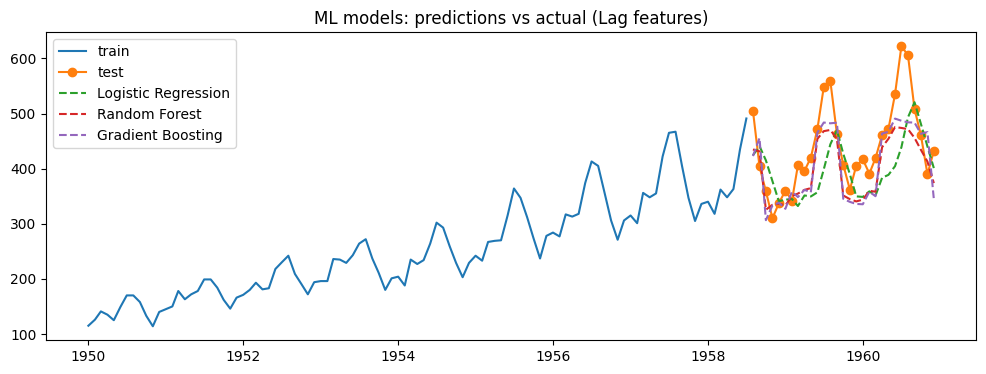

In [61]:
print(f"Linear Regression - MSE: {lr_mse:.2f}, MAE: {lr_mae:.2f}")
print(f"Random Forest - MSE: {rf_mse:.2f}, MAE: {rf_mae:.2f}")
print(f"Gradient Boosting - MSE: {gb_mse:.2f}, MAE: {gb_mae:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(y_train.index, y_train.values, label='train')
ax.plot(test_data_orig.index, test_data_orig.values, label='test', marker='o')
ax.plot(test_data_orig.index, lr_preds, label='Logistic Regression', linestyle='--')
ax.plot(test_data_orig.index, rf_preds, label='Random Forest', linestyle='--')
ax.plot(test_data_orig.index, gb_preds, label='Gradient Boosting', linestyle='--')
ax.set_title('ML models: predictions vs actual (Lag features)')
ax.legend()
plt.show()

Both Random Forest and Gradient Boosting models outperformed the Logistic Regression model with MAE's of 47.32 and 48.90 respectively compared to 62.50 for Logistic Regression. All three models were able to capture the trend in the data as well as the seasonality to some extent. For sure missing are the encoded month features which could help the models better capture seasonality. Overall, the ML models performed reasonably well but were outperformed by the simpler statistical models as well as the DNN.

# 5. Statistical Models (ARIMA & ETS)

Training SARIMA and ETS models that explicitly handle seasonality and trend

Based on ACF/PACF analysis and stationarity tests, we'll use SARIMA. The data shows strong seasonality (period=12) and trend.

In [ ]:
sarima = SARIMAX(
    train_data_orig,
    order=(0,1,1),
    seasonal_order=(0,1,1,12),
    enforce_invertibility=False,
    enforce_stationarity=False
)
sarima_res = sarima.fit(disp=False)
sarima_preds = sarima_res.predict(start=test_data_orig.index[0], end=test_data_orig.index[-1])
sarima_mse = mean_squared_error(test_data_orig, sarima_preds)
sarima_mae = mean_absolute_error(test_data_orig, sarima_preds)

In [ ]:
# ETS Model
ets = ExponentialSmoothing(
    train_data_orig,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
)
ets_fit = ets.fit(optimized=True)
ets_preds = ets_fit.forecast(steps=len(test_data_orig))
ets_mse = mean_squared_error(test_data_orig, ets_preds)
ets_mae = mean_absolute_error(test_data_orig, ets_preds)

SARMIA - MSE: 935.14, MAE: 24.06
ETS - MSE: 678.14, MAE: 21.96


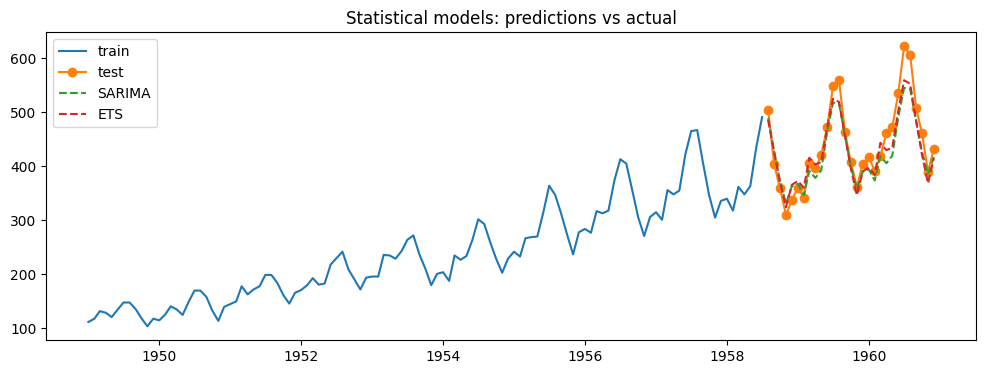

In [64]:
print(f"SARMIA - MSE: {sarima_mse:.2f}, MAE: {sarima_mae:.2f}")
print(f"ETS - MSE: {ets_mse:.2f}, MAE: {ets_mae:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_data_orig.index, train_data_orig.values, label='train')
ax.plot(test_data_orig.index, test_data_orig.values, label='test', marker='o')
ax.plot(test_data_orig.index, sarima_preds, label='SARIMA', linestyle='--')
ax.plot(test_data_orig.index, ets_preds, label='ETS', linestyle='--')
ax.set_title('Statistical models: predictions vs actual')
ax.legend()
plt.show()

Both statistical approaches performed very well, with ETS slightly outperforming SARIMA. Both models capture the seasonal pattern as well as the positive trend with similar high accuracy. However, the increase in variance over time is not very well captured by either model, leading to clear underestimation during peak months in later years. Overall, ETS achieved the second-best performance (on non-stationary data) with a MAE of 21.96 only losing out to the DNN model that was able to better capture the increasing variance and therefore predicting the peaks in the data more accurately.